# Thống kê số lượng nhãn chính (L1)

Notebook này đọc dữ liệu từ `raw_data.json` và vẽ biểu đồ phân bố số lượng theo `label_l1`.

In [41]:
import json
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [42]:
DATA_FILE = r'C:\Users\Admin\Documents\nlp\NLP_Project\data\raw\raw_data1.json'

with open(DATA_FILE, 'r', encoding='utf-8') as f:
    data = json.load(f)

len(data)

11799

In [43]:
label_counts = Counter(item.get('label_l1', '').strip() for item in data)
if '' in label_counts:
    del label_counts['']

df = (
    pd.DataFrame(label_counts.items(), columns=['label_l1', 'count'])
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)
df['percent'] = (df['count'] / df['count'].sum() * 100).round(2)
df

,label_l1,count,percent
0,Giải trí,1356,11.49
1,Sức khỏe,1145,9.70
2,Thể thao,1007,8.53
3,Thời sự,1005,8.52
4,Khoa học công nghệ,997,8.45
5,Giáo dục,881,7.47
6,Thế giới,867,7.35
7,Pháp luật,819,6.94
8,Du lịch,818,6.93
9,Khoa học,804,6.81


C:\Users\Admin\AppData\Local\Temp\ipykernel_8936\3326662964.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='label_l1', y='count', palette='Blues_r')


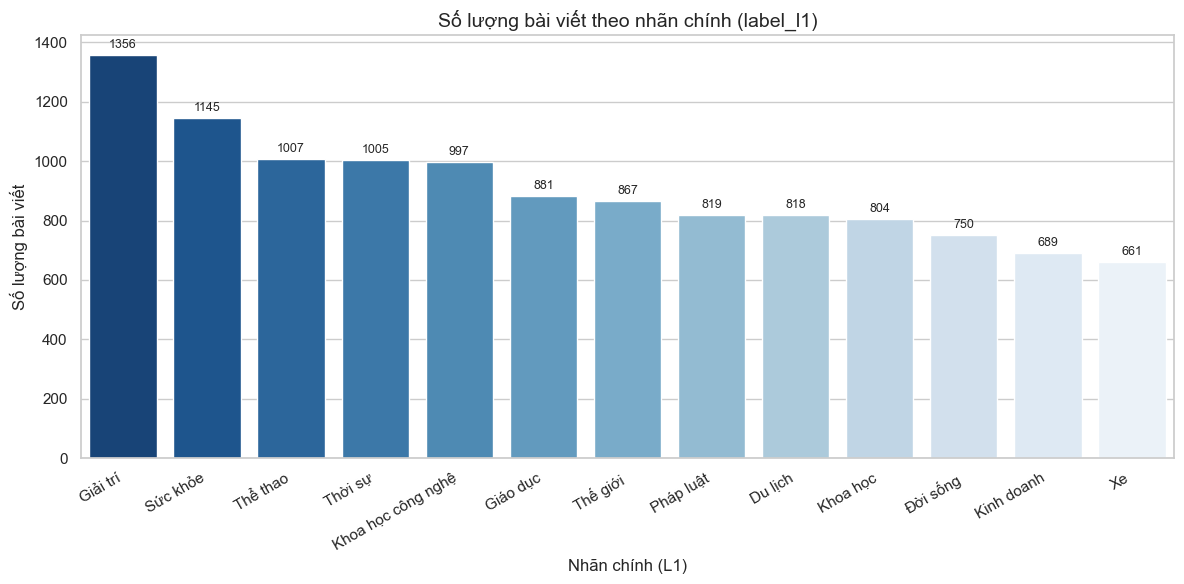

In [44]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df, x='label_l1', y='count', palette='Blues_r')

for i, v in enumerate(df['count']):
    ax.text(i, v + max(df['count']) * 0.01, str(v), ha='center', va='bottom', fontsize=9)

plt.title('Số lượng bài viết theo nhãn chính (label_l1)', fontsize=14)
plt.xlabel('Nhãn chính (L1)')
plt.ylabel('Số lượng bài viết')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

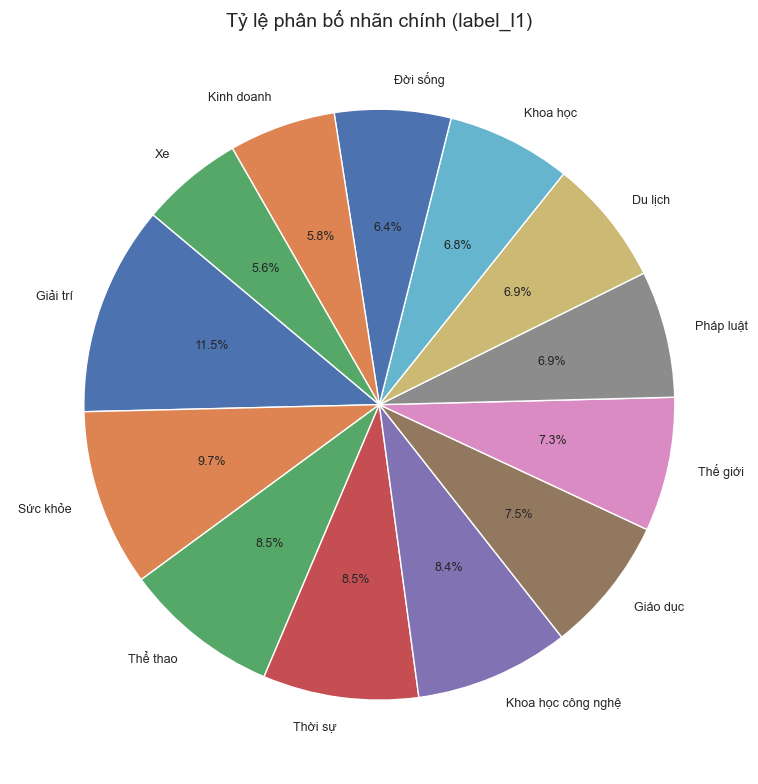

In [45]:
plt.figure(figsize=(8, 8))
plt.pie(
    df['count'],
    labels=df['label_l1'],
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 9}
)
plt.title('Tỷ lệ phân bố nhãn chính (label_l1)', fontsize=14)
plt.tight_layout()
plt.show()

In [46]:
# Nếu cần lưu bảng thống kê ra CSV
# df.to_csv('label_l1_stats.csv', index=False, encoding='utf-8-sig')
df.head(20)

,label_l1,count,percent
0,Giải trí,1356,11.49
1,Sức khỏe,1145,9.70
2,Thể thao,1007,8.53
3,Thời sự,1005,8.52
4,Khoa học công nghệ,997,8.45
5,Giáo dục,881,7.47
6,Thế giới,867,7.35
7,Pháp luật,819,6.94
8,Du lịch,818,6.93
9,Khoa học,804,6.81


## Thống kê nhãn cấp 2 (L2) và cấp 3 (L3)

Các biểu đồ dưới đây hiển thị **toàn bộ nhãn không rỗng** của `label_l2` và `label_l3`.

In [47]:
def build_label_stats(data, field_name):
    counts = Counter(item.get(field_name, '').strip() for item in data)
    if '' in counts:
        del counts['']

    df_stats = (
        pd.DataFrame(counts.items(), columns=[field_name, 'count'])
        .sort_values('count', ascending=False)
        .reset_index(drop=True)
    )
    df_stats['percent'] = (df_stats['count'] / df_stats['count'].sum() * 100).round(2)
    return df_stats


def plot_all_labels(df_stats, label_col, title):
    fig_height = max(6, len(df_stats) * 0.35)
    plt.figure(figsize=(14, fig_height))
    ax = sns.barplot(data=df_stats, y=label_col, x='count', palette='viridis')

    for i, value in enumerate(df_stats['count']):
        ax.text(value + max(df_stats['count']) * 0.005, i, str(value), va='center', fontsize=9)

    plt.title(title, fontsize=14)
    plt.xlabel('Số lượng bài viết')
    plt.ylabel('Nhãn')
    plt.tight_layout()
    plt.show()

Số nhãn label_l2 (không rỗng): 97


,label_l2,count,percent
0,Các bệnh,781,7.71
1,Tin tức,705,6.96
2,Bóng đá,372,3.67
3,Thế giới tự nhiên,324,3.20
4,Nhịp sống,318,3.14
...,...,...,...
92,VnExpress Youth Basketball 2025,1,0.01
93,"Trao dấu yêu, giữ sức khỏe",1,0.01
94,Hệ sinh thái PC AI của HP,1,0.01
95,Phòng vệ HPV,1,0.01


C:\Users\Admin\AppData\Local\Temp\ipykernel_8936\1556584629.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_stats, y=label_col, x='count', palette='viridis')


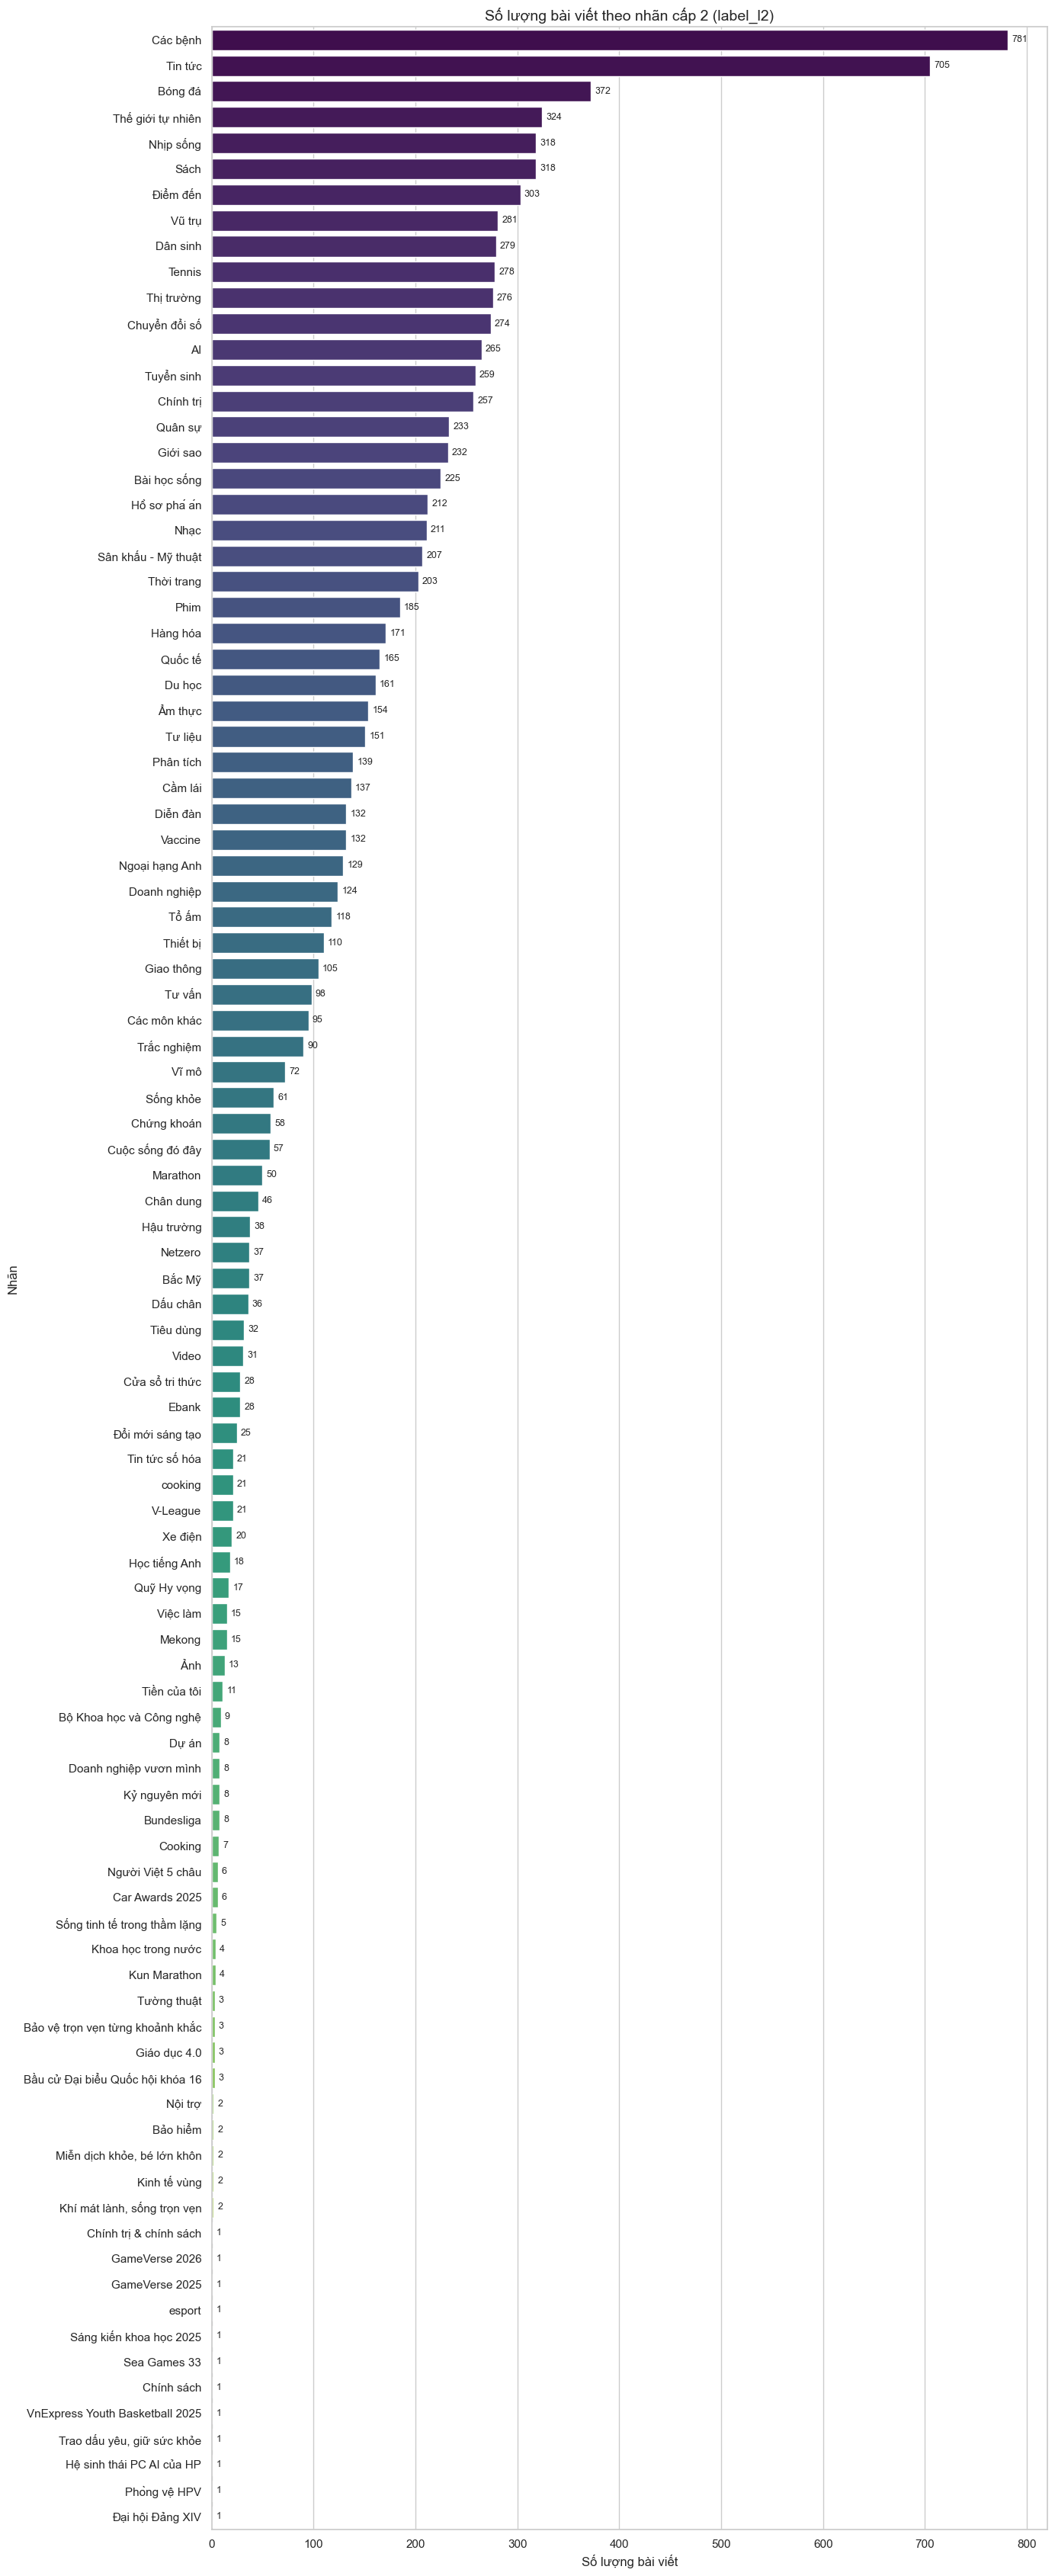

In [48]:
# Thống kê và vẽ biểu đồ cho label_l2

df_l2 = build_label_stats(data, 'label_l2')
print(f"Số nhãn label_l2 (không rỗng): {len(df_l2)}")
display(df_l2)

plot_all_labels(
    df_l2,
    label_col='label_l2',
    title='Số lượng bài viết theo nhãn cấp 2 (label_l2)'
)

Số nhãn label_l3 (không rỗng): 115


,label_l3,count,percent
0,Trong nước,218,5.45
1,Đại học,212,5.30
2,Làng nhạc,205,5.12
3,Tin tức,194,4.85
4,Chuyện màn ảnh,174,4.35
...,...,...,...
110,Ngân hàng sáng tạo,1,0.02
111,Nông nghiệp,1,0.02
112,Câu chuyện ngành,1,0.02
113,Độ xe,1,0.02


C:\Users\Admin\AppData\Local\Temp\ipykernel_8936\1556584629.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_stats, y=label_col, x='count', palette='viridis')


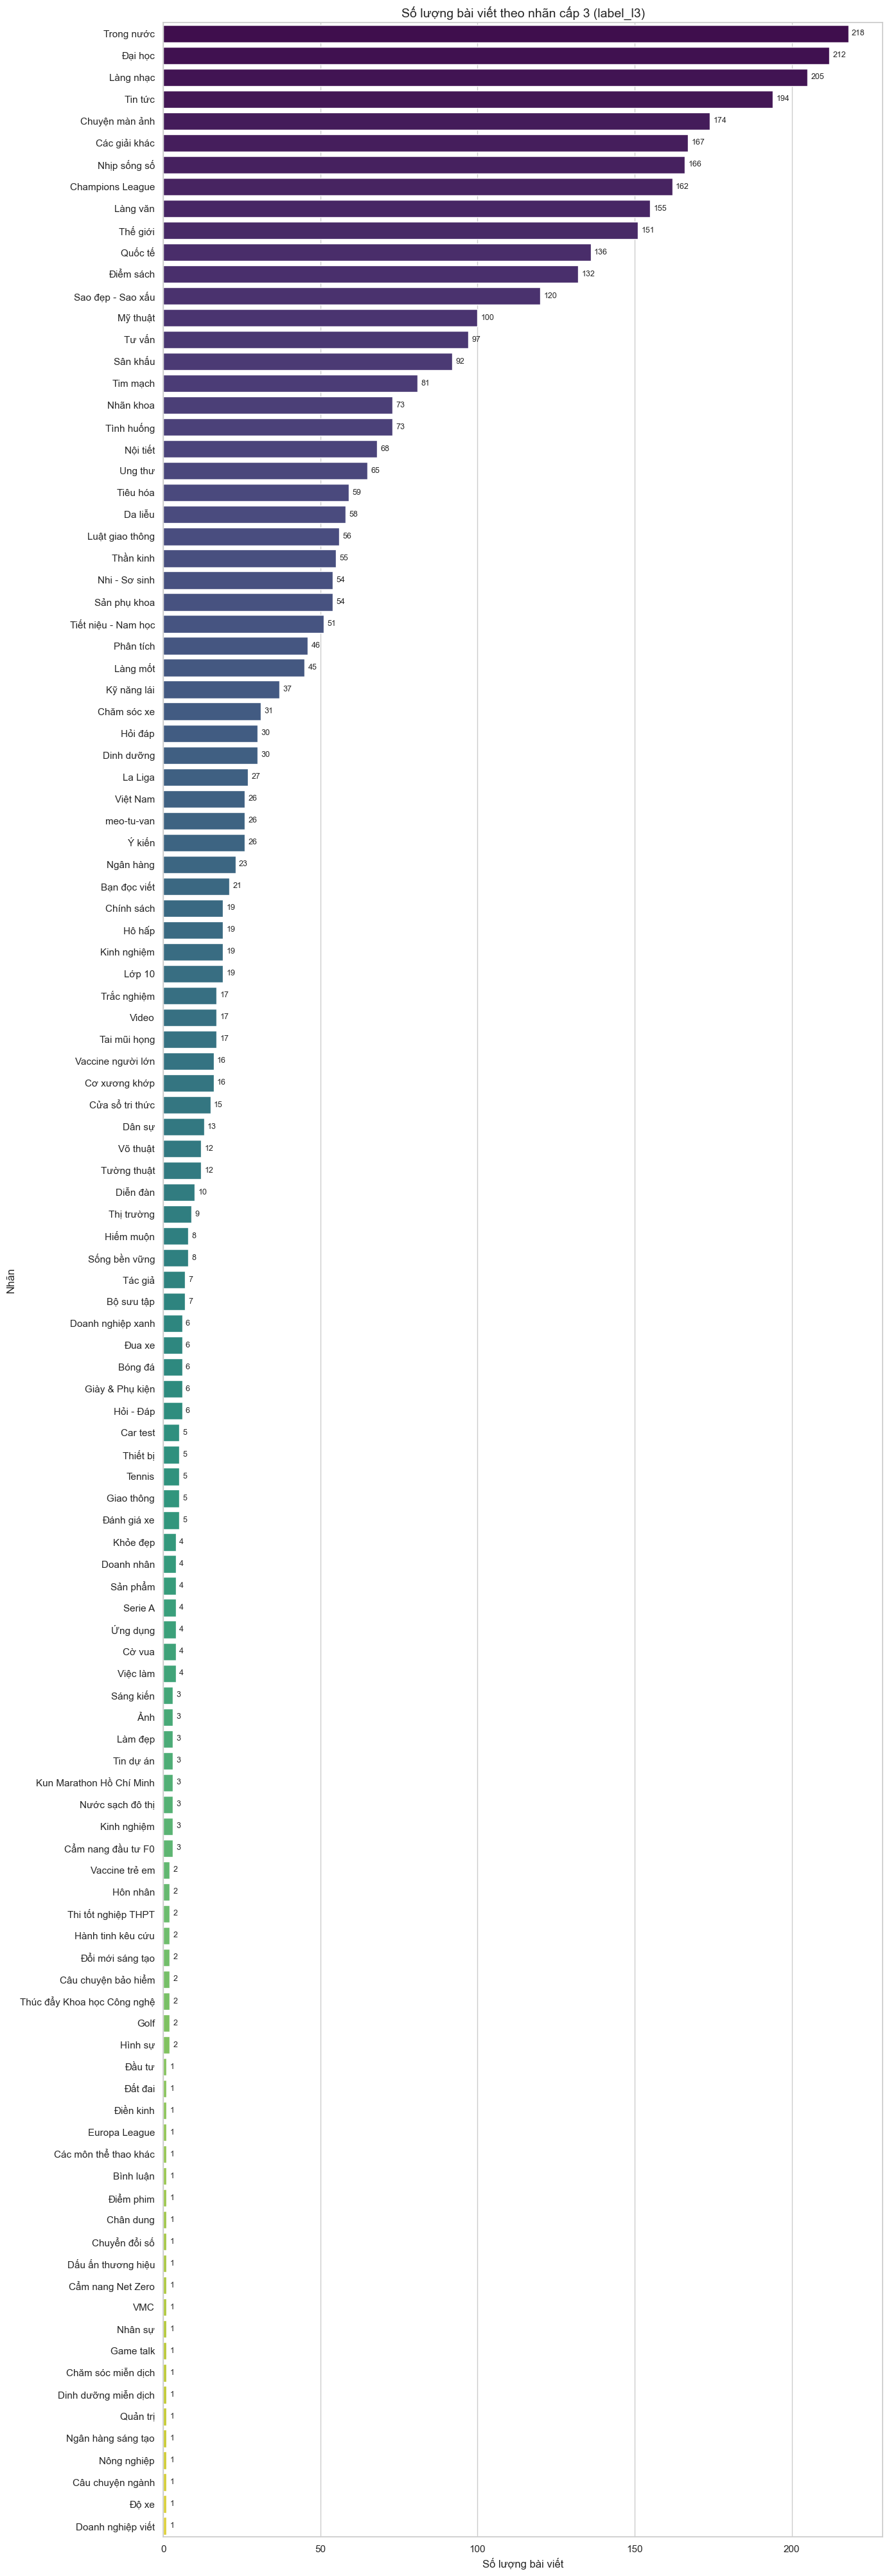

In [49]:
# Thống kê và vẽ biểu đồ cho label_l3

df_l3 = build_label_stats(data, 'label_l3')
print(f"Số nhãn label_l3 (không rỗng): {len(df_l3)}")
display(df_l3)

plot_all_labels(
    df_l3,
    label_col='label_l3',
    title='Số lượng bài viết theo nhãn cấp 3 (label_l3)'
)

## Thống kê nhãn sau tiền xử lý (dataset.json)

Đọc từ `dataset.json` — dữ liệu đã qua normalize, merge, drop nhãn.
So sánh với raw để thấy bao nhiêu bài/nhãn bị lọc.


Tổng bài sau tiền xử lý: 11,787
Tổng bài raw            : 11,799
Bị lọc bỏ              : 12 (0.1%)

Số nhãn L1 unique: 13
Số nhãn L2 unique: 44  (bài có L2: 9,585 = 81.3%)
Số nhãn L3 unique: 22  (bài có L3: 2,603 = 22.1%)

  PHÂN PHỐI L1 (sau tiền xử lý)


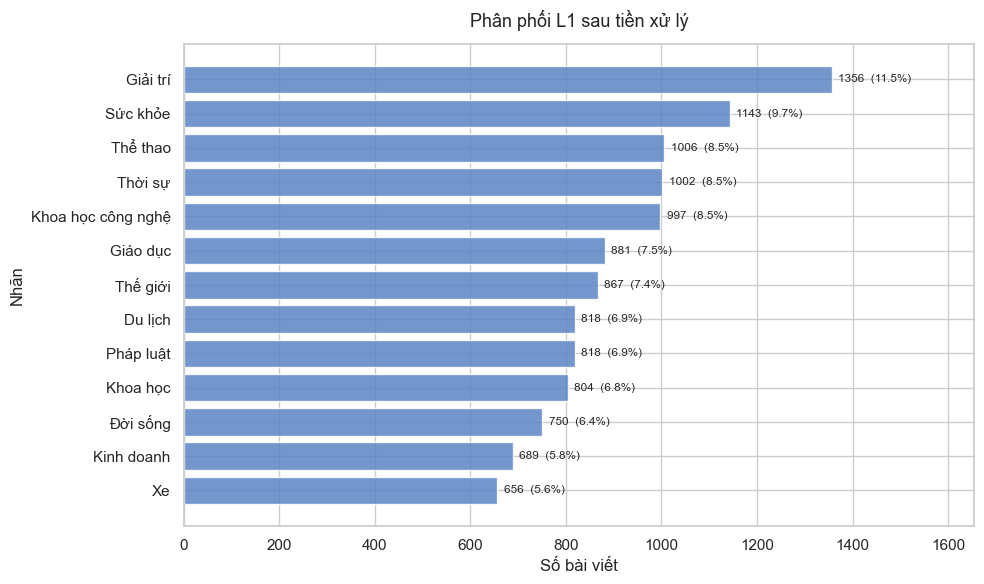

,label,số bài,%
0,Giải trí,1356,11.504200
1,Sức khỏe,1143,9.697124
2,Thể thao,1006,8.534827
3,Thời sự,1002,8.500891
4,Khoa học công nghệ,997,8.458471
5,Giáo dục,881,7.474336
6,Thế giới,867,7.355561
7,Du lịch,818,6.939849
8,Pháp luật,818,6.939849
9,Khoa học,804,6.821074



  PHÂN PHỐI L2 (sau tiền xử lý)


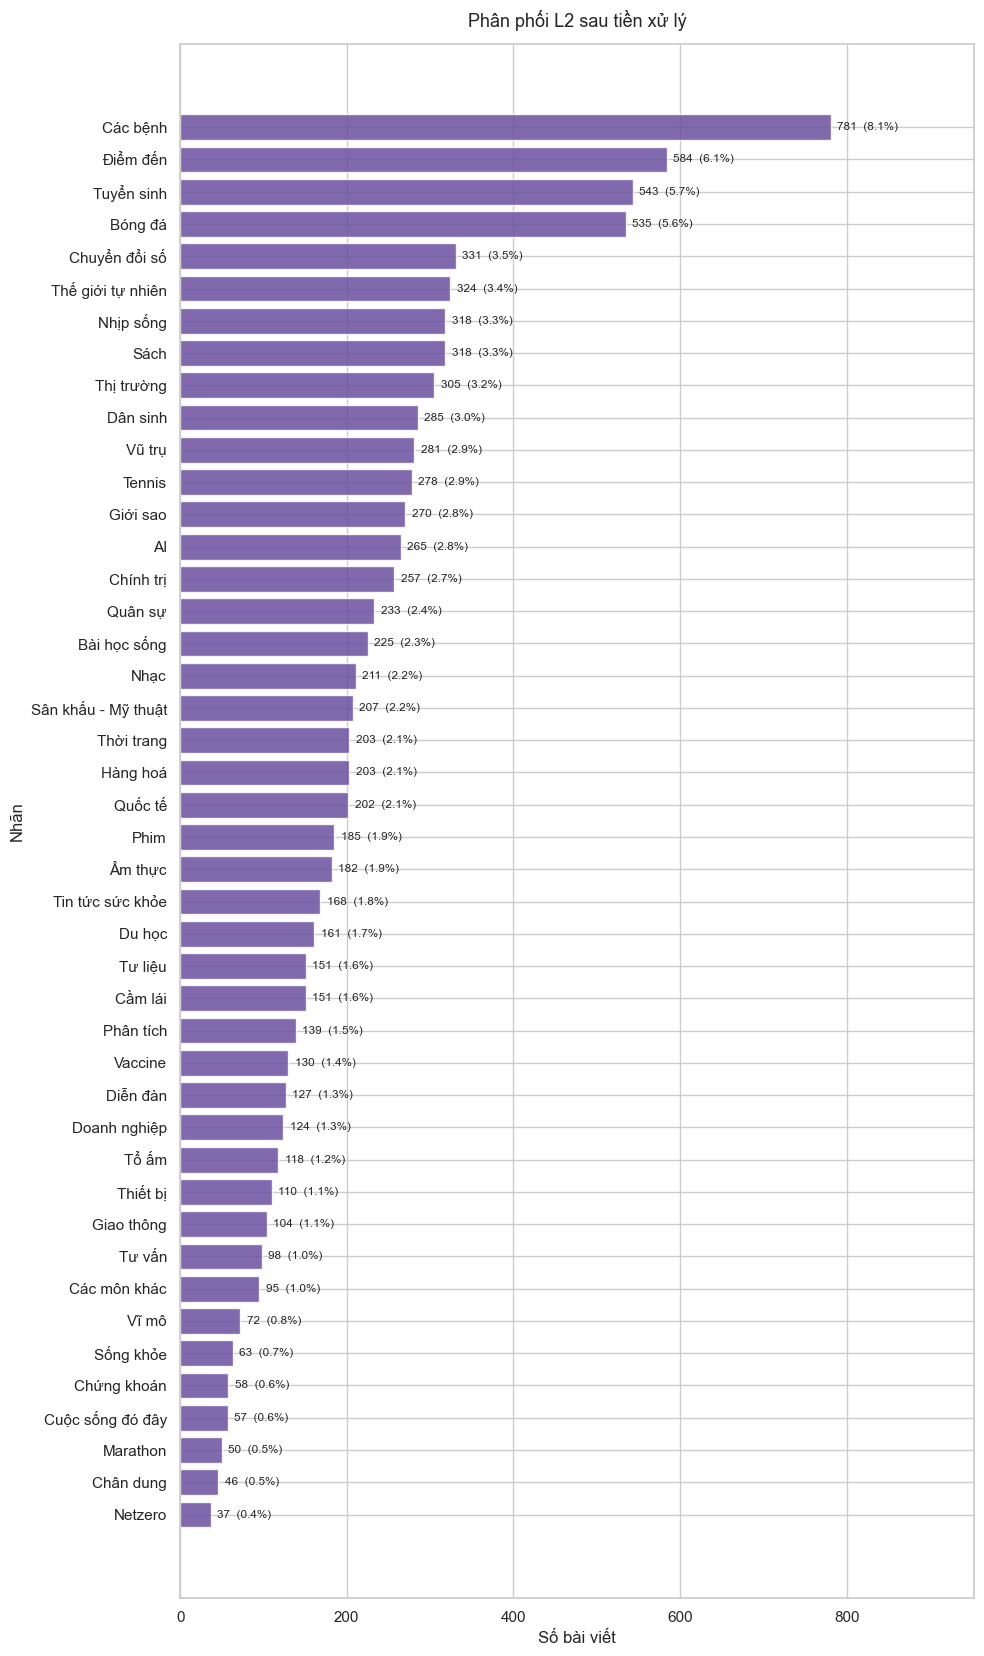

,label,số bài,%
0,Các bệnh,781,8.148148
1,Điểm đến,584,6.092853
2,Tuyển sinh,543,5.665102
3,Bóng đá,535,5.581638
4,Chuyển đổi số,331,3.453312
5,Thế giới tự nhiên,324,3.380282
6,Nhịp sống,318,3.317684
7,Sách,318,3.317684
8,Thị trường,305,3.182055
9,Dân sinh,285,2.973396



  PHÂN PHỐI L3 (sau tiền xử lý)


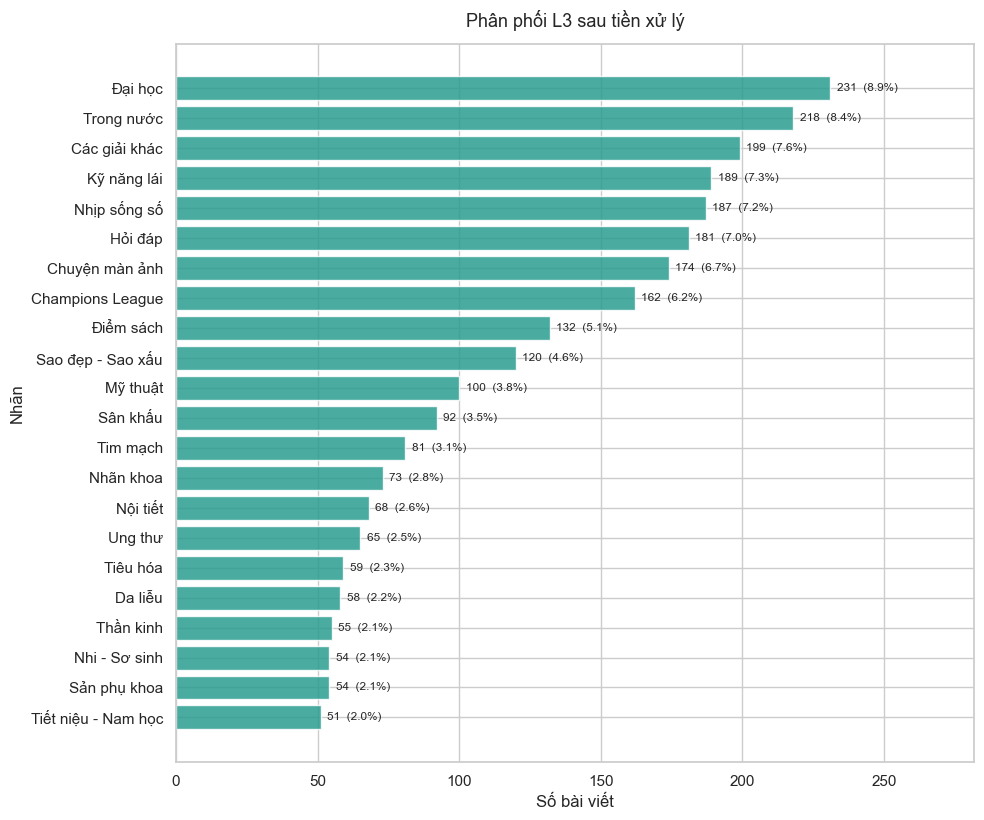

,label,số bài,%
0,Đại học,231,8.874376
1,Trong nước,218,8.374952
2,Các giải khác,199,7.645025
3,Kỹ năng lái,189,7.260853
4,Nhịp sống số,187,7.184018
5,Hỏi đáp,181,6.953515
6,Chuyện màn ảnh,174,6.684595
7,Champions League,162,6.223588
8,Điểm sách,132,5.071072
9,Sao đẹp - Sao xấu,120,4.610065



  SO SÁNH RAW vs SAU TIỀN XỬ LÝ
                              Raw    Processed     Giảm
  -------------------------------------------------------
  Tổng bài                 11,799       11,787       12
  Nhãn L1 unique               13           13        0
  Nhãn L2 unique               97           44       53
  Nhãn L3 unique              115           22       93


In [50]:
import json, pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATASET_FILE = r'C:\Users\Admin\Documents\nlp\NLP_Project\data\process_data\dataset.json'

with open(DATASET_FILE, encoding='utf-8') as f:
    dataset = json.load(f)

print(f'Tổng bài sau tiền xử lý: {len(dataset):,}')
print(f'Tổng bài raw            : {len(data):,}')
print(f'Bị lọc bỏ              : {len(data)-len(dataset):,} ({(len(data)-len(dataset))/len(data)*100:.1f}%)')
print()

# ── Đếm nhãn ─────────────────────────────────────────────────────────────
c_l1 = Counter(a['labels_l1'][0] for a in dataset if a['labels_l1'])
c_l2 = Counter(a['labels_l2'][0] for a in dataset if a['labels_l2'])
c_l3 = Counter(a['labels_l3'][0] for a in dataset if a['labels_l3'])

has_l2 = sum(1 for a in dataset if a['labels_l2'])
has_l3 = sum(1 for a in dataset if a['labels_l3'])

print(f'Số nhãn L1 unique: {len(c_l1)}')
print(f'Số nhãn L2 unique: {len(c_l2)}  (bài có L2: {has_l2:,} = {has_l2/len(dataset)*100:.1f}%)')
print(f'Số nhãn L3 unique: {len(c_l3)}  (bài có L3: {has_l3:,} = {has_l3/len(dataset)*100:.1f}%)')

# ── Hàm vẽ bar chart ──────────────────────────────────────────────────────
def plot_label_dist(counter, title, figsize, fig_color='#5B84C4'):
    df = (pd.DataFrame(counter.items(), columns=['label', 'count'])
            .sort_values('count', ascending=False)
            .reset_index(drop=True))
    df['percent'] = df['count'] / df['count'].sum() * 100

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(df['label'][::-1], df['count'][::-1], color=fig_color, alpha=0.85)

    max_count = df['count'].max()
    for bar, (_, row) in zip(bars, df[::-1].iterrows()):
        ax.text(bar.get_width() + max_count * 0.01, bar.get_y() + bar.get_height()/2,
                f"{int(row['count'])}  ({row['percent']:.1f}%)",
                va='center', fontsize=8.5)

    ax.set_xlim(0, max_count * 1.22)
    ax.set_xlabel('Số bài viết')
    ax.set_ylabel('Nhãn')
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    plt.show()
    return df

# ── L1 ────────────────────────────────────────────────────────────────────
print('\n' + '='*55)
print('  PHÂN PHỐI L1 (sau tiền xử lý)')
print('='*55)
df_l1_post = plot_label_dist(c_l1, 'Phân phối L1 sau tiền xử lý', figsize=(10, 6))
display(df_l1_post.rename(columns={'count':'số bài','percent':'%'}))

# ── L2 ────────────────────────────────────────────────────────────────────
print('\n' + '='*55)
print('  PHÂN PHỐI L2 (sau tiền xử lý)')
print('='*55)
df_l2_post = plot_label_dist(
    c_l2, 'Phân phối L2 sau tiền xử lý',
    figsize=(10, max(6, len(c_l2) * 0.38)), fig_color='#6B4FA0'
)
display(df_l2_post.rename(columns={'count':'số bài','percent':'%'}))

# ── L3 ────────────────────────────────────────────────────────────────────
print('\n' + '='*55)
print('  PHÂN PHỐI L3 (sau tiền xử lý)')
print('='*55)
df_l3_post = plot_label_dist(
    c_l3, 'Phân phối L3 sau tiền xử lý',
    figsize=(10, max(6, len(c_l3) * 0.38)), fig_color='#2A9D8F'
)
display(df_l3_post.rename(columns={'count':'số bài','percent':'%'}))

# ── So sánh raw vs processed ──────────────────────────────────────────────
print('\n' + '='*55)
print('  SO SÁNH RAW vs SAU TIỀN XỬ LÝ')
print('='*55)
raw_l1 = Counter(item.get('label_l1','').strip() for item in data if item.get('label_l1','').strip())
raw_l2 = Counter(item.get('label_l2','').strip() for item in data if item.get('label_l2','').strip())
raw_l3 = Counter(item.get('label_l3','').strip() for item in data if item.get('label_l3','').strip())

print(f'  {"":20} {"Raw":>10} {"Processed":>12} {"Giảm":>8}')
print(f'  {"-"*55}')
print(f'  {"Tổng bài":<20} {len(data):>10,} {len(dataset):>12,} {len(data)-len(dataset):>8,}')
print(f'  {"Nhãn L1 unique":<20} {len(raw_l1):>10} {len(c_l1):>12} {len(raw_l1)-len(c_l1):>8}')
print(f'  {"Nhãn L2 unique":<20} {len(raw_l2):>10} {len(c_l2):>12} {len(raw_l2)-len(c_l2):>8}')
print(f'  {"Nhãn L3 unique":<20} {len(raw_l3):>10} {len(c_l3):>12} {len(raw_l3)-len(c_l3):>8}')
